# WoFS Rollout Visualization

This notebook visualizes:
- Rollout metrics CSV: `/tmp/credit_wofs_rollout_example/rollout_metrics.csv`
- Rollout forecast outputs directory: `/tmp/credit_wofs_rollout_example/wofs_20190703_0000_mem01`
  - Supports either a Zarr store or a directory of NetCDF (`*.nc`) forecast files.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

In [2]:
metrics_path = Path('/tmp/credit_wofs_rollout_example/rollout_metrics.csv')
rollout_path = Path('/tmp/credit_wofs_rollout_example/wofs_20190703_0000_mem01')

print('Metrics path exists :', metrics_path.exists(), metrics_path)
print('Rollout path exists :', rollout_path.exists(), rollout_path)
if rollout_path.exists() and rollout_path.is_dir():
    nc_files = sorted(rollout_path.glob('*.nc'))
    print(f'NetCDF files found  : {len(nc_files)}')

Metrics path exists : True /tmp/credit_wofs_rollout_example/rollout_metrics.csv
Rollout path exists : True /tmp/credit_wofs_rollout_example/wofs_20190703_0000_mem01
NetCDF files found  : 36


## 1) Rollout metrics CSV

In [3]:
df = pd.read_csv(metrics_path)
print('Shape:', df.shape)
display(df.head())

id_cols = [c for c in ['case', 'forecast_hour', 'datetime', 'forecast_step'] if c in df.columns]
metric_cols = [c for c in df.columns if c not in id_cols]
print('ID columns    :', id_cols)
print('Metric columns:', len(metric_cols))
print(metric_cols[:20])

Shape: (36, 454)


,case,forecast_hour,acc_T_0,rmse_T_0,mse_T_0,mae_T_0,acc_T_1,rmse_T_1,mse_T_1,mae_T_1,...,mse_LWP,mae_LWP,acc_RAIN_AMOUNT,rmse_RAIN_AMOUNT,mse_RAIN_AMOUNT,mae_RAIN_AMOUNT,acc,rmse,mse,mae
0,wofs_20190703_0000_mem01,1,0.991302,0.845721,0.715245,0.504573,0.993127,0.739762,0.547247,0.438735,...,74099.750000,97.535988,0.806135,0.317067,0.100532,0.097290,0.941091,93.142113,54295.585938,48.500237
1,wofs_20190703_0000_mem01,2,0.986731,0.999590,0.999181,0.629452,0.988785,0.900704,0.811268,0.571423,...,114162.109375,107.807236,0.827004,0.341071,0.116330,0.097545,0.907058,125.317383,98569.875000,64.311470
2,wofs_20190703_0000_mem01,3,0.982601,1.109210,1.230346,0.736212,0.984823,1.020316,1.041045,0.691459,...,138757.796875,117.719574,0.780732,0.481486,0.231829,0.115614,0.876454,147.027222,135897.515625,75.145683
3,wofs_20190703_0000_mem01,4,0.978690,1.202961,1.447116,0.834769,0.981109,1.123948,1.263259,0.797131,...,154756.796875,125.574455,0.694203,0.612983,0.375748,0.136013,0.855416,164.257843,169821.578125,83.419418
4,wofs_20190703_0000_mem01,5,0.974407,1.298607,1.686379,0.930944,0.977119,1.228002,1.507988,0.898934,...,163402.359375,130.809814,0.645367,0.741801,0.550268,0.154628,0.830953,178.450226,200650.078125,89.798233


ID columns    : ['case', 'forecast_hour']
Metric columns: 452
['acc_T_0', 'rmse_T_0', 'mse_T_0', 'mae_T_0', 'acc_T_1', 'rmse_T_1', 'mse_T_1', 'mae_T_1', 'acc_T_2', 'rmse_T_2', 'mse_T_2', 'mae_T_2', 'acc_T_3', 'rmse_T_3', 'mse_T_3', 'mae_T_3', 'acc_T_4', 'rmse_T_4', 'mse_T_4', 'mae_T_4']


,acc_T_0,rmse_T_0,mse_T_0,mae_T_0,acc_T_1,rmse_T_1,mse_T_1,mae_T_1,acc_T_2,rmse_T_2,...,mse_LWP,mae_LWP,acc_RAIN_AMOUNT,rmse_RAIN_AMOUNT,mse_RAIN_AMOUNT,mae_RAIN_AMOUNT,acc,rmse,mse,mae
forecast_hour,,,,,,,,,,,,,,,,,,,,,
1,0.991302,0.845721,0.715245,0.504573,0.993127,0.739762,0.547247,0.438735,0.993727,0.692631,...,74099.750000,97.535988,0.806135,0.317067,0.100532,0.097290,0.941091,93.142113,54295.585938,48.500237
2,0.986731,0.999590,0.999181,0.629452,0.988785,0.900704,0.811268,0.571423,0.989435,0.868408,...,114162.109375,107.807236,0.827004,0.341071,0.116330,0.097545,0.907058,125.317383,98569.875000,64.311470
3,0.982601,1.109210,1.230346,0.736212,0.984823,1.020316,1.041045,0.691459,0.985651,0.997607,...,138757.796875,117.719574,0.780732,0.481486,0.231829,0.115614,0.876454,147.027222,135897.515625,75.145683
4,0.978690,1.202961,1.447116,0.834769,0.981109,1.123948,1.263259,0.797131,0.982107,1.108527,...,154756.796875,125.574455,0.694203,0.612983,0.375748,0.136013,0.855416,164.257843,169821.578125,83.419418
5,0.974407,1.298607,1.686379,0.930944,0.977119,1.228002,1.507988,0.898934,0.978297,1.220434,...,163402.359375,130.809814,0.645367,0.741801,0.550268,0.154628,0.830953,178.450226,200650.078125,89.798233


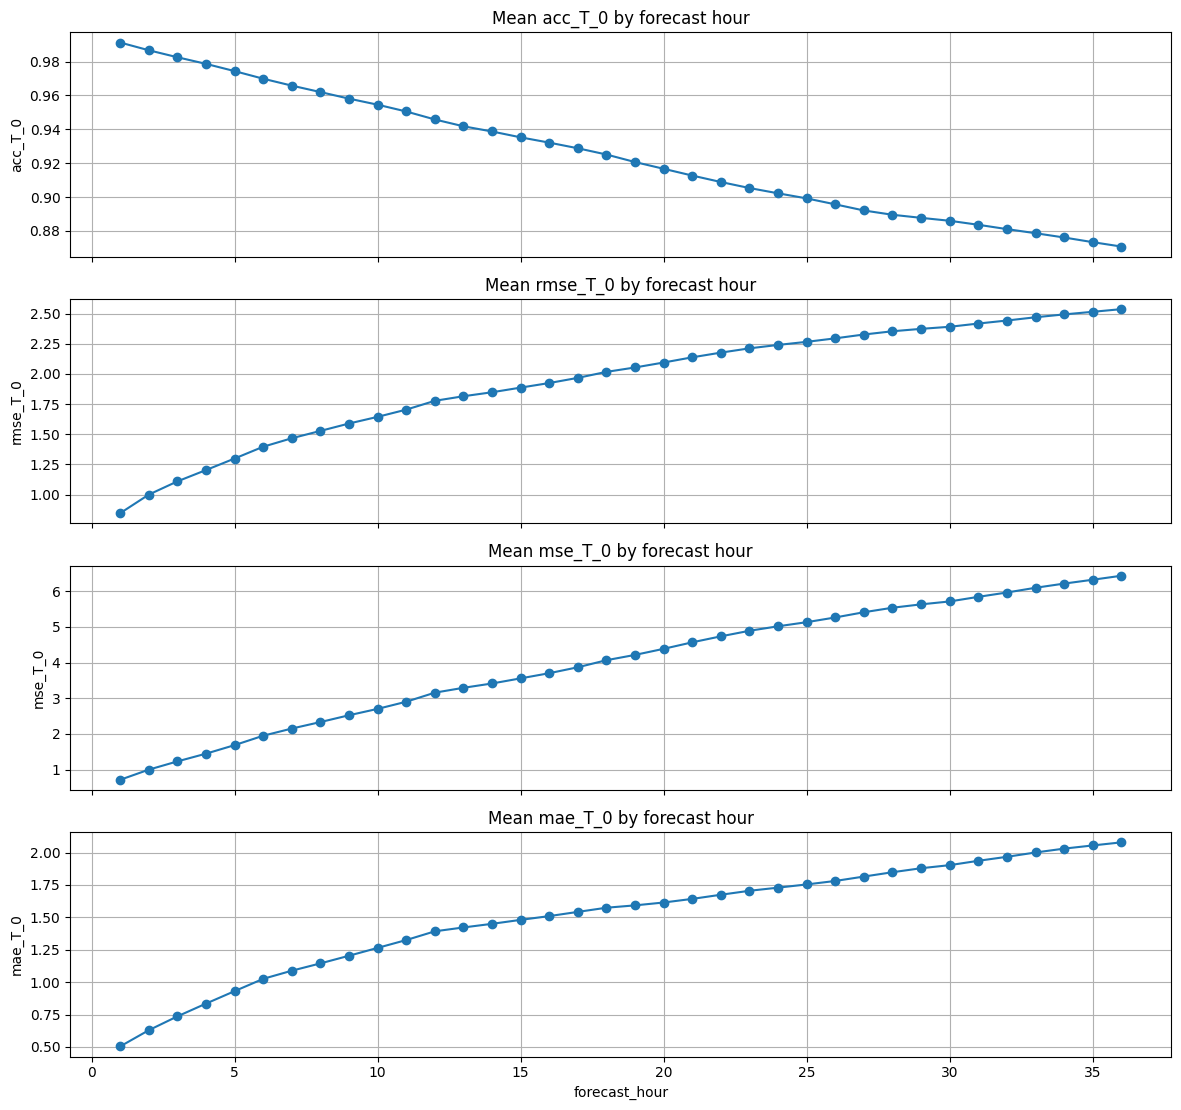

In [4]:
if 'forecast_hour' in df.columns and len(metric_cols) > 0:
    summary = df.groupby('forecast_hour')[metric_cols].mean(numeric_only=True).sort_index()
    display(summary.head())

    n_plot = min(4, len(summary.columns))
    fig, axes = plt.subplots(n_plot, 1, figsize=(12, 2.8 * n_plot), sharex=True)
    if n_plot == 1:
        axes = [axes]

    for ax, col in zip(axes, summary.columns[:n_plot]):
        ax.plot(summary.index, summary[col], marker='o')
        ax.set_ylabel(col)
        ax.set_title(f'Mean {col} by forecast hour')

    axes[-1].set_xlabel('forecast_hour')
    plt.tight_layout()
    plt.show()
else:
    print('Could not plot by forecast hour (missing forecast_hour or metric columns).')

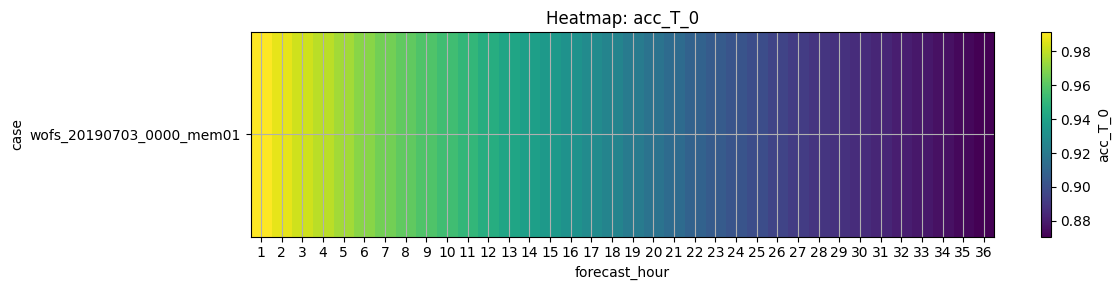

In [5]:
if {'case', 'forecast_hour'}.issubset(df.columns) and len(metric_cols) > 0:
    selected_metric = metric_cols[0]
    pivot = df.pivot_table(index='case', columns='forecast_hour', values=selected_metric, aggfunc='mean')

    plt.figure(figsize=(12, max(3, 0.35 * len(pivot.index))))
    im = plt.imshow(pivot.values, aspect='auto', interpolation='nearest')
    plt.colorbar(im, label=selected_metric)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=0)
    plt.xlabel('forecast_hour')
    plt.ylabel('case')
    plt.title(f'Heatmap: {selected_metric}')
    plt.tight_layout()
    plt.show()
else:
    print('Could not draw heatmap; need case, forecast_hour, and at least one metric column.')

## 2) Rollout Zarr visualization

In [11]:
# Auto-detect rollout format: NetCDF directory vs Zarr store
nc_files = sorted(rollout_path.glob('*.nc')) if rollout_path.is_dir() else []

if len(nc_files) > 0:
    ds = xr.open_mfdataset(
        [str(p) for p in nc_files],
        combine='nested',
        concat_dim='time',
        engine='netcdf4',
    )
    print(f'Opened {len(nc_files)} NetCDF files via open_mfdataset')
else:
    ds = xr.open_zarr(rollout_path)
    print('Opened rollout as Zarr store')

data_vars = list(ds.data_vars)
print(ds)
print('\nVariables:')
print(data_vars)

Opened 36 NetCDF files via open_mfdataset
<xarray.Dataset> Size: 1GB
Dimensions:    (time: 36, level: 17, latitude: 300, longitude: 300)
Coordinates:
  * time       (time) datetime64[ns] 288B 2019-07-04T00:10:00 ... 2019-07-04T...
  * level      (level) int64 136B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
  * latitude   (latitude) int64 2kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
  * longitude  (longitude) int64 2kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
Data variables:
    T          (time, level, latitude, longitude) float32 220MB dask.array<chunksize=(1, 17, 300, 300), meta=np.ndarray>
    QVAPOR     (time, level, latitude, longitude) float32 220MB dask.array<chunksize=(1, 17, 300, 300), meta=np.ndarray>
    U          (time, level, latitude, longitude) float32 220MB dask.array<chunksize=(1, 17, 300, 300), meta=np.ndarray>
    V          (time, level, latitude, longitude) float32 220MB dask.array<chunksize=(1, 17, 300, 300), meta=np.ndarray>
    W          (time, level, latitude

In [12]:
# Interactive controls for variable/time selection (with animation play control)
if HAS_WIDGETS:
    default_var = 'COMPOSITE_REFL_10CM' if 'COMPOSITE_REFL_10CM' in data_vars else data_vars[0]
    max_time_idx = max(int(ds.sizes.get('time', 1)) - 1, 0)
    var_dropdown = widgets.Dropdown(
        options=data_vars,
        value=default_var,
        description='Variable:',
        layout=widgets.Layout(width='450px')
    )
    time_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=max_time_idx,
        step=1,
        description='Time idx:',
        continuous_update=False,
        layout=widgets.Layout(width='450px')
    )
    play = widgets.Play(
        value=0,
        min=0,
        max=max_time_idx,
        step=1,
        interval=350,
        description='Play'
    )
    widgets.jslink((play, 'value'), (time_slider, 'value'))
    display(widgets.VBox([var_dropdown, widgets.HBox([play, time_slider])]))
    print('Use controls, then run Cells 12 and 13 for updated plots.')
else:
    selected_var = 'COMPOSITE_REFL_10CM' if 'COMPOSITE_REFL_10CM' in data_vars else data_vars[0]
    selected_time_idx = 0
    print('ipywidgets not available. Using selected_var and selected_time_idx fallback values.')

Use controls, then run Cells 12 and 13 for updated plots.


In [13]:
# Load matching ground-truth WoFS case from the original cases directory
truth_root = Path('/work2/zhanxianghua/wofs_preprocess_to_credit/cases')
truth_case_path = truth_root / f"{rollout_path.name}.zarr"
gt_ds = None

if truth_case_path.exists():
    gt_ds = xr.open_zarr(truth_case_path)
    print('Loaded ground-truth case:', truth_case_path)
    print(gt_ds)
else:
    print('Ground-truth case not found:', truth_case_path)

Loaded ground-truth case: /work2/zhanxianghua/wofs_preprocess_to_credit/cases/wofs_20190703_0000_mem01.zarr
<xarray.Dataset> Size: 2GB
Dimensions:                 (time: 37, y: 300, x: 300, level: 17)
Coordinates:
  * time                    (time) datetime64[ns] 296B 2019-07-04 ... 2019-07...
    trajectory_id           (time) float64 296B dask.array<chunksize=(1,), meta=np.ndarray>
  * y                       (y) int64 2kB 0 1 2 3 4 5 ... 295 296 297 298 299
  * x                       (x) int64 2kB 0 1 2 3 4 5 ... 295 296 297 298 299
    latitude                (y, x) float32 360kB dask.array<chunksize=(300, 300), meta=np.ndarray>
    longitude               (y, x) float32 360kB dask.array<chunksize=(300, 300), meta=np.ndarray>
  * level                   (level) int64 136B 0 1 2 3 4 5 ... 11 12 13 14 15 16
Data variables: (12/32)
    COMPOSITE_REFL_10CM     (time, y, x) float32 13MB dask.array<chunksize=(1, 300, 300), meta=np.ndarray>
    GEOPOT                  (time, level, y, x)

In [ ]:
def pick_slice(da: xr.DataArray, time_idx: int = 0):
    indexers = {}
    if 'time' in da.dims:
        indexers['time'] = min(time_idx, int(da.sizes['time']) - 1)
    if 'level' in da.dims:
        indexers['level'] = 0
    elif 'lev' in da.dims:
        indexers['lev'] = 0
    return da.isel(**indexers) if indexers else da

def scalar_from_da(da: xr.DataArray) -> float:
    reduced = da.compute() if hasattr(da, 'compute') else da
    return float(np.asarray(reduced.values).squeeze())

if HAS_WIDGETS and 'var_dropdown' in globals() and 'time_slider' in globals():
    var_to_plot = var_dropdown.value
    time_idx = int(time_slider.value)
else:
    var_to_plot = selected_var if 'selected_var' in globals() else data_vars[0]
    time_idx = int(selected_time_idx) if 'selected_time_idx' in globals() else 0

pred_field = pick_slice(ds[var_to_plot], time_idx=time_idx).squeeze()

gt_field = None
if 'gt_ds' in globals() and gt_ds is not None and var_to_plot in gt_ds.data_vars:
    gt_field = pick_slice(gt_ds[var_to_plot], time_idx=time_idx).squeeze()

print('Selected variable:', var_to_plot)
print('Selected time idx:', time_idx)
print('Pred slice dims:', pred_field.dims, 'shape:', pred_field.shape)
if gt_field is not None:
    print('GT   slice dims:', gt_field.dims, 'shape:', gt_field.shape)

if pred_field.ndim == 2:
    if gt_field is not None and gt_field.ndim == 2 and pred_field.shape == gt_field.shape:
        err = pred_field - gt_field
        pred_min = scalar_from_da(pred_field.min(skipna=True))
        gt_min = scalar_from_da(gt_field.min(skipna=True))
        pred_max = scalar_from_da(pred_field.max(skipna=True))
        gt_max = scalar_from_da(gt_field.max(skipna=True))
        vmin = float(np.nanmin([pred_min, gt_min]))
        vmax = float(np.nanmax([pred_max, gt_max]))

        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
        pred_field.plot(ax=axes[0], cmap='viridis', vmin=vmin, vmax=vmax, add_colorbar=True)
        axes[0].set_title(f'Prediction: {var_to_plot}')

        gt_field.plot(ax=axes[1], cmap='viridis', vmin=vmin, vmax=vmax, add_colorbar=True)
        axes[1].set_title(f'Ground Truth: {var_to_plot}')

        err.plot(ax=axes[2], cmap='RdBu_r', add_colorbar=True)
        axes[2].set_title('Prediction - Ground Truth')
        plt.suptitle(f'Time idx={time_idx}')
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(8, 6))
        pred_field.plot(cmap='viridis')
        plt.title(f'{var_to_plot} prediction (time idx={time_idx})')
        plt.tight_layout()
        plt.show()
else:
    print('Field is not 2D after slicing. Inspect manually:')
    display(pred_field)

Selected variable: T
Selected time idx: 35
Pred slice dims: ('latitude', 'longitude') shape: (300, 300)
GT   slice dims: ('y', 'x') shape: (300, 300)


NotImplementedError: 'item' is not yet a valid method on dask arrays

ValueError: x and y can be no greater than 2D, but have shapes (36,) and (36, 300, 300)

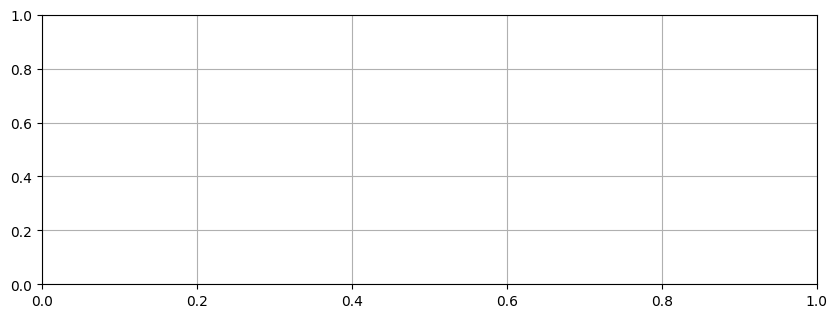

In [15]:
if HAS_WIDGETS and 'var_dropdown' in globals() and 'time_slider' in globals():
    var_for_timeseries = var_dropdown.value
else:
    var_for_timeseries = selected_var if 'selected_var' in globals() else data_vars[0]

da_pred = ds[var_for_timeseries]
da_truth = None
if 'gt_ds' in globals() and gt_ds is not None and var_for_timeseries in gt_ds.data_vars:
    da_truth = gt_ds[var_for_timeseries]

if 'time' in da_pred.dims:
    indexers = {}
    if 'level' in da_pred.dims:
        indexers['level'] = 0
    elif 'lev' in da_pred.dims:
        indexers['lev'] = 0

    if 'y' in da_pred.dims and 'x' in da_pred.dims:
        indexers['y'] = da_pred.sizes['y'] // 2
        indexers['x'] = da_pred.sizes['x'] // 2
    elif 'south_north' in da_pred.dims and 'west_east' in da_pred.dims:
        indexers['south_north'] = da_pred.sizes['south_north'] // 2
        indexers['west_east'] = da_pred.sizes['west_east'] // 2

    ts_pred = da_pred.isel(**indexers).squeeze()
    ts_pred_np = np.asarray((ts_pred.compute() if hasattr(ts_pred, 'compute') else ts_pred).values)

    plt.figure(figsize=(10, 3.5))
    plt.plot(np.arange(ts_pred_np.shape[0]), ts_pred_np, marker='o', label='Prediction')

    if da_truth is not None:
        truth_indexers = {k: v for k, v in indexers.items() if k in da_truth.dims}
        ts_truth = da_truth.isel(**truth_indexers).squeeze()
        ts_truth_np = np.asarray((ts_truth.compute() if hasattr(ts_truth, 'compute') else ts_truth).values)
        n = min(ts_pred_np.shape[0], ts_truth_np.shape[0])
        plt.plot(np.arange(n), ts_truth_np[:n], marker='x', linestyle='--', label='Ground Truth')

    plt.title(f'Time series at center point: {var_for_timeseries}')
    plt.xlabel('Time index')
    plt.ylabel(var_for_timeseries)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f'{var_for_timeseries} has no time dimension.')

In [ ]:
# Optional: animated map playback (requires ipywidgets)
if HAS_WIDGETS and 'var_dropdown' in globals() and 'time_slider' in globals():
    from IPython.display import clear_output

    output = widgets.Output()

    def draw_for_time(change=None):
        with output:
            clear_output(wait=True)
            var = var_dropdown.value
            t = int(time_slider.value)
            da_pred = ds[var]
            idx = {'time': min(t, int(da_pred.sizes['time']) - 1)} if 'time' in da_pred.dims else {}
            if 'level' in da_pred.dims:
                idx['level'] = 0
            elif 'lev' in da_pred.dims:
                idx['lev'] = 0
            frame = da_pred.isel(**idx).squeeze()
            if frame.ndim == 2:
                plt.figure(figsize=(7, 5))
                frame.plot(cmap='viridis')
                plt.title(f'{var} | time idx={t}')
                plt.tight_layout()
                plt.show()
            else:
                print('Animated frame is not 2D for this variable.')

    var_dropdown.observe(draw_for_time, names='value')
    time_slider.observe(draw_for_time, names='value')
    draw_for_time()
    display(output)
else:
    print('ipywidgets not available; animation controls are disabled.')